### Optimizing Time Series Forecasting: A Comparative Study of Adam and Nesterov Accelerated Gradient on LSTM and GRU networks Using Stock Market data - Experiments Code

## Step 1: Libary Imports

In [1]:
# Import necessary libraries for data
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tabulate import tabulate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

import yfinance as yf
from datetime import datetime

# Define the stock ticker and date range
stock_ticker = 'AAPL'
start_date = '2014-01-01'
end_date = '2024-08-01'


## Step 2: Data Preparation and Splitting


### Proposed DAIN

In [2]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

class DAIN_Layer(nn.Module):
    def __init__(self, mode='full', isTarget=False, mean_lr=0.00001, gate_lr=0.001, scale_lr=0.00001, input_dim=144):
        super(DAIN_Layer, self).__init__()
        self.mode = mode
        self.isTarget = isTarget
        self.mean_lr = mean_lr
        self.gate_lr = gate_lr
        self.scale_lr = scale_lr
        self.mean_layer = nn.Linear(input_dim, input_dim, bias=False)
        self.mean_layer.weight.data = torch.FloatTensor(data=np.eye(input_dim, input_dim))
        self.scaling_layer = nn.Linear(input_dim, input_dim, bias=False)
        self.scaling_layer.weight.data = torch.FloatTensor(data=np.eye(input_dim, input_dim))
        self.gating_layer = nn.Linear(input_dim, input_dim)
        self.eps = 1e-8

    def forward(self, x):
        if self.mode == 'full':
           # Step 1:
            avg = torch.mean(x, 2)
            adaptive_avg = self.mean_layer(avg)
            adaptive_avg = adaptive_avg.reshape(adaptive_avg.size(0), adaptive_avg.size(1), 1)
            x = x - adaptive_avg

            # # Step 2:
            std = torch.mean(x ** 2, 2)
            std = torch.sqrt(std + self.eps)
            adaptive_std = self.scaling_layer(std)
            adaptive_std[adaptive_std <= self.eps] = 1

            adaptive_std = adaptive_std.reshape(adaptive_std.size(0), adaptive_std.size(1), 1)
            x = x / adaptive_std

            # Step 3: 
            avg = torch.mean(x, 2)
            gate = F.sigmoid(self.gating_layer(avg))
            gate = gate.reshape(gate.size(0), gate.size(1), 1)
            x = x * gate
        else:
            raise ValueError("Unknown mode")

        if self.isTarget:
            return x, adaptive_avg, adaptive_std, gate
        else: 
            return x

In [3]:
def inverse_dain(data, adaptive_avg, adaptive_std, gate):
    """
    Inverse of the adaptive_scale operation.

    Args:
        data:           pd.DataFrame  (n_samples, n_features)
                        torch.Tensor  (batch_size, 1, n_features) from DataLoader
                        np.ndarray    (n_samples, n_features)
        adaptive_avg:   tensor from dain forward pass, shape (1, n_features, 1)
        adaptive_std:   tensor from dain forward pass, shape (1, n_features, 1)

    Returns:
        Same type as input — pd.DataFrame, torch.Tensor, or np.ndarray
    """
    if isinstance(data, pd.DataFrame):
        cols, idx = data.columns, data.index
        x = torch.tensor(data.values, dtype=torch.float32).T.unsqueeze(0)
        x = x / gate
        x = (x * adaptive_std) + adaptive_avg
        x = x.squeeze(0).T.numpy()
        return pd.DataFrame(x, columns=cols, index=idx)

    elif isinstance(data, torch.Tensor):
        x = data.squeeze(1).T.unsqueeze(0)   # (1, n_features, batch_size)
        x = x / gate
        x = (x * adaptive_std) + adaptive_avg
        return x.squeeze(0).T.unsqueeze(1)    # (batch_size, 1, n_features)

    elif isinstance(data, np.ndarray):
        was_1d = data.ndim == 1
        if was_1d:
            data = data.reshape(-1, 1)
        x = torch.tensor(data, dtype=torch.float32).T.unsqueeze(0)
        x = x / gate
        x = (x * adaptive_std) + adaptive_avg
        result = x.squeeze(0).T.numpy()
        if was_1d:
            result = result.ravel()
        return result

    else:
        raise TypeError(f"Expected pd.DataFrame, torch.Tensor, or np.ndarray, got {type(data)}")

In [4]:
def apply_dain(df, dain):  
    cols = df.columns
    idx = df.index
    x = torch.tensor(df.values, dtype=torch.float32)
    x = x.T.unsqueeze(0)
    with torch.no_grad():
        result = dain(x) 
    if dain.isTarget:
        normalized, adaptive_avg, adaptive_std, gate = result
        normalized = normalized.squeeze(0).T.numpy()
        return pd.DataFrame(normalized, columns=cols, index=idx), adaptive_avg, adaptive_std, gate
    else:
        normalized = result.squeeze(0).T.numpy()
        return pd.DataFrame(normalized, columns=cols, index=idx)

### Proposed CEEMDAN

In [5]:
!pip install EMD-signal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 4.3 MB/s eta 0:00:00


In [6]:
from PyEMD import EMD, EEMD, CEEMDAN
import numpy as np

In [7]:
def apply_ceemdan(df, ceemdan):
    all_imfs = {}
    for col in df.columns:
        signal = df[col].to_numpy(dtype=np.float64)
        imfs = ceemdan(signal)
        all_imfs[col] = imfs
    return all_imfs

In [8]:
import pywt

def wavelet_denoise(signal, wavelet='db4', level=None, mode='soft'):
    if level is None:
        level = pywt.dwt_max_level(len(signal), wavelet)
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(signal)))
    denoised_coeffs = [coeffs[0]]
    for detail in coeffs[1:]:
        denoised_coeffs.append(pywt.threshold(detail, threshold, mode=mode))
    denoised = pywt.waverec(denoised_coeffs, wavelet)
    return denoised[:len(signal)]

def apply_wavelet_denoise(all_imfs):
    all_imfs_denoised = {}
    for col, imfs in all_imfs.items():
        denoised_imfs = np.zeros_like(imfs)
        for i in range(imfs.shape[0]):
            denoised_imfs[i] = wavelet_denoise(imfs[i])
        all_imfs_denoised[col] = denoised_imfs
        print(f"{col}: {imfs.shape[0]} IMFs denoised")
    return all_imfs_denoised

In [9]:
def reconstruct_imfs(denoised_imfs, df):
    reconstructed_data = {}
    for col, imfs in denoised_imfs.items():
        reconstructed_data[col] = np.sum(imfs, axis=0)
    return pd.DataFrame(reconstructed_data, index=df.index)

In [10]:
def plot_ceemdan_imfs(all_imfs, column='Close', filename='ceemdan_imfs.png'):
    imfs = all_imfs[column]
    n_imfs = imfs.shape[0]
    t = np.arange(imfs.shape[1])
    
    fig, axes = plt.subplots(n_imfs, 1, figsize=(9, 2 * n_imfs), sharex=True)
    
    if n_imfs == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(t, imfs[i], 'k-', linewidth=0.7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.text(1.01, 0.5, f'IMF {i + 1}', transform=ax.transAxes, va='center', fontsize=9)

    axes[-1].set_xlabel('Time Steps')
    fig.subplots_adjust(hspace=0.3, right=0.85)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [11]:
def apply_ceemdan_denoise(data, ceemdan, split):
    ceemdan_data = apply_ceemdan(pd.DataFrame(data, columns=['Close']), ceemdan)
    denoised_data = apply_wavelet_denoise(ceemdan_data)
    
    if split == 'train':
        ceemdan_denoised_train_data = reconstruct_imfs(denoised_data, df.iloc[:training_data_len])
        plot_ceemdan_imfs(ceemdan_data, 'Close', filename="ceemdan_imfs_train_3.png")
        plot_ceemdan_imfs(denoised_data, 'Close', filename="denoised_imfs_train_3.png")
        return ceemdan_denoised_train_data
    elif split == 'val': 
        ceemdan_denoised_val_data = reconstruct_imfs(denoised_data, df.iloc[training_data_len:validation_data_len])
        plot_ceemdan_imfs(ceemdan_data, 'Close', filename="ceemdan_imfs_val_3.png")
        plot_ceemdan_imfs(denoised_data, 'Close', filename="denoised_imfs_val_3.png")
        return ceemdan_denoised_val_data
    elif split == 'test': 
        ceemdan_denoised_test_reconstructed = reconstruct_imfs(denoised_data, df.iloc[validation_data_len:])
        plot_ceemdan_imfs(ceemdan_data, 'Close', filename="ceemdan_imfs_test_3.png")
        plot_ceemdan_imfs(denoised_data, 'Close', filename="denoised_imfs_test_3.png")
        return ceemdan_denoised_test_reconstructed

### The rest of the steps continue

In [12]:
df = yf.download(stock_ticker, start=start_date, end=end_date, multi_level_index=False)

# Filters the 'Close' column
data = df.filter(['Close'])
data

/tmp/ipykernel_23/4001820110.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock_ticker, start=start_date, end=end_date, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close
Date,
2014-01-02,17.124889
2014-01-03,16.748726
2014-01-06,16.840059
2014-01-07,16.719622
2014-01-08,16.825500
...,...
2024-07-25,215.622192
2024-07-26,216.088150
2024-07-29,216.365753


In [13]:
# Convert the dataframe to a numpy array
dataset = data.values

# Split the dataset into training, validation, and test sets
training_data_len = int(np.ceil(len(dataset) * 0.70))
validation_data_len = int(np.ceil(len(dataset) * 0.85))

train_data = dataset[:training_data_len, :]
val_data = dataset[training_data_len:validation_data_len, :]
test_data = dataset[validation_data_len:, :]

print(f"Training Data Length: {len(train_data)}")
print(f"Validation Data Length: {len(val_data)}")
print(f"Test Data Length: {len(test_data)}")


Training Data Length: 1864
Validation Data Length: 399
Test Data Length: 399


In [14]:
ceemdan = CEEMDAN(trials=100, parallel=True) 

### Raw IMFs

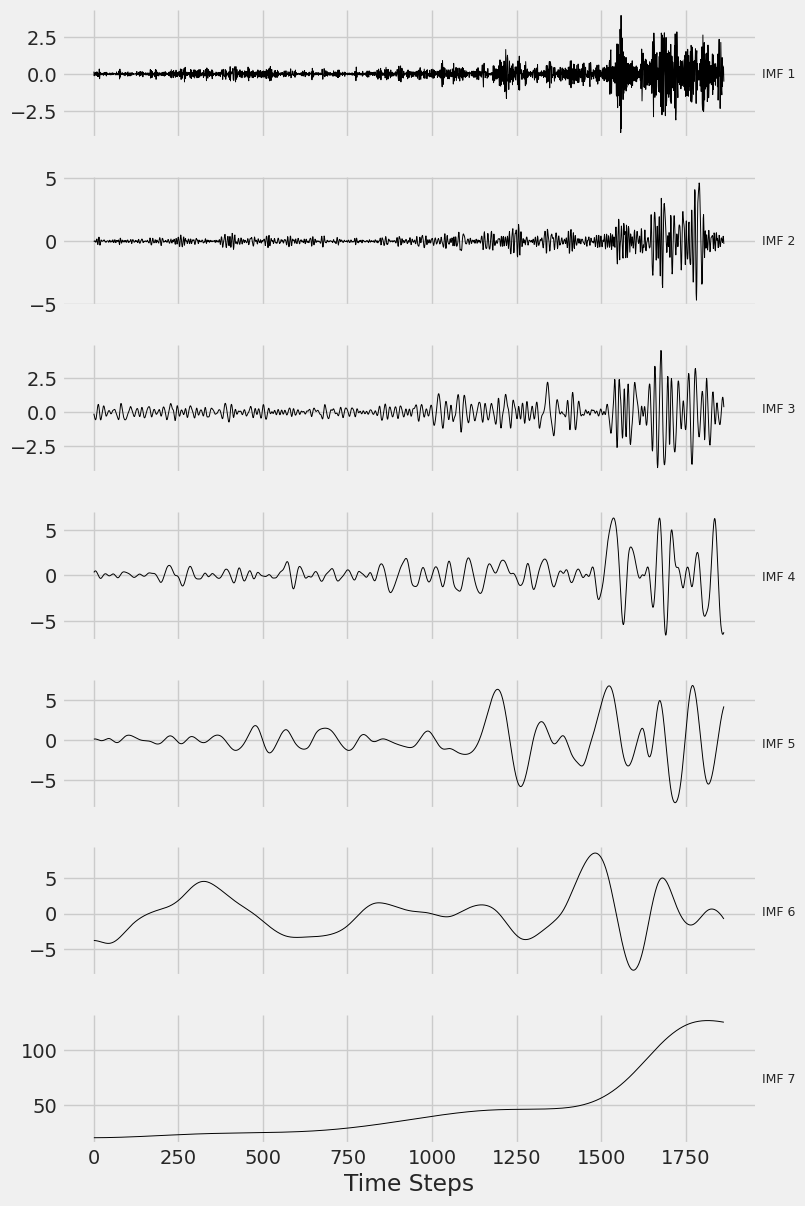

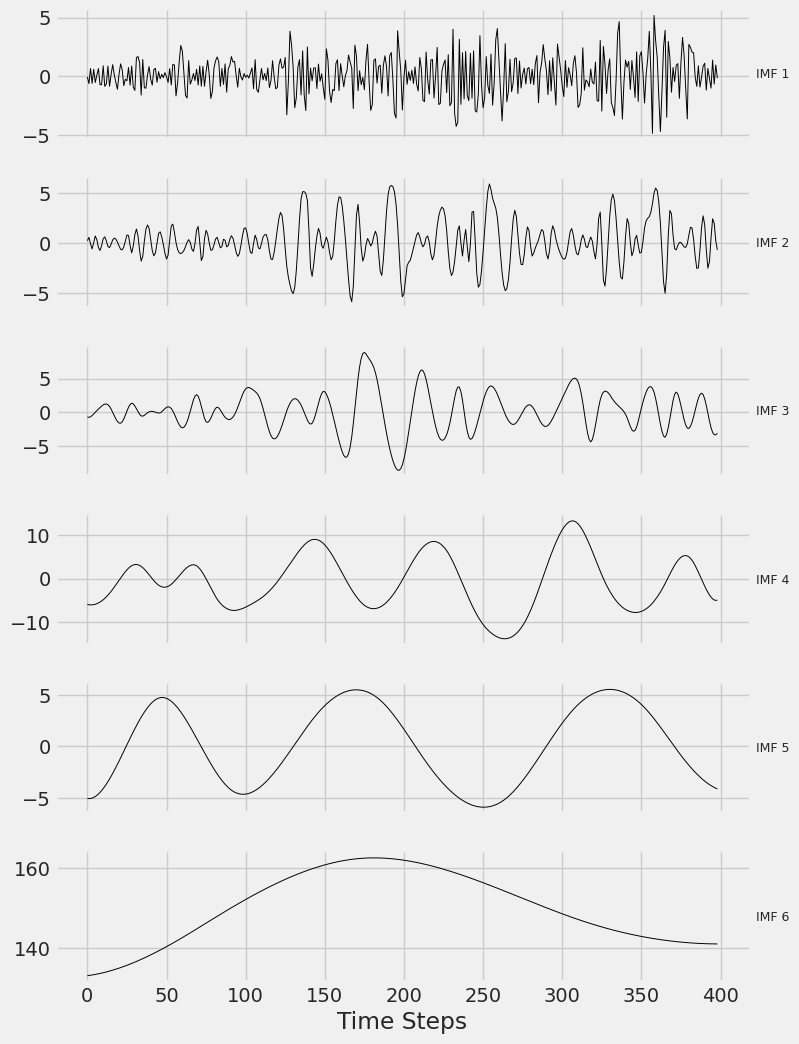

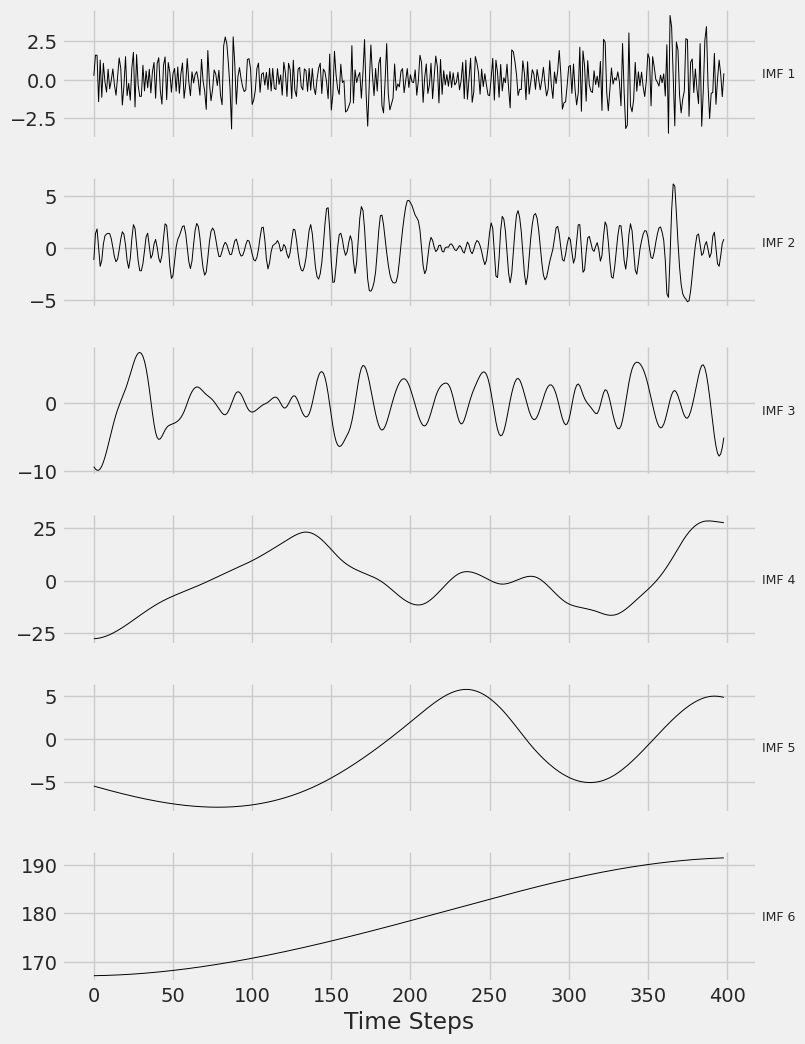

In [15]:
# IMFs of raw Close prices (no scaling / no DAIN)
raw_imfs_train = apply_ceemdan(pd.DataFrame(train_data, columns=['Close']), ceemdan)
raw_imfs_val   = apply_ceemdan(pd.DataFrame(val_data, columns=['Close']), ceemdan)
raw_imfs_test  = apply_ceemdan(pd.DataFrame(test_data, columns=['Close']), ceemdan)

plot_ceemdan_imfs(raw_imfs_train, 'Close', filename='raw_ceemdan_imfs_train.png')
plot_ceemdan_imfs(raw_imfs_val,   'Close', filename='raw_ceemdan_imfs_val.png')
plot_ceemdan_imfs(raw_imfs_test,  'Close', filename='raw_ceemdan_imfs_test.png')

### Denoised IMFs

Close: 7 IMFs denoised


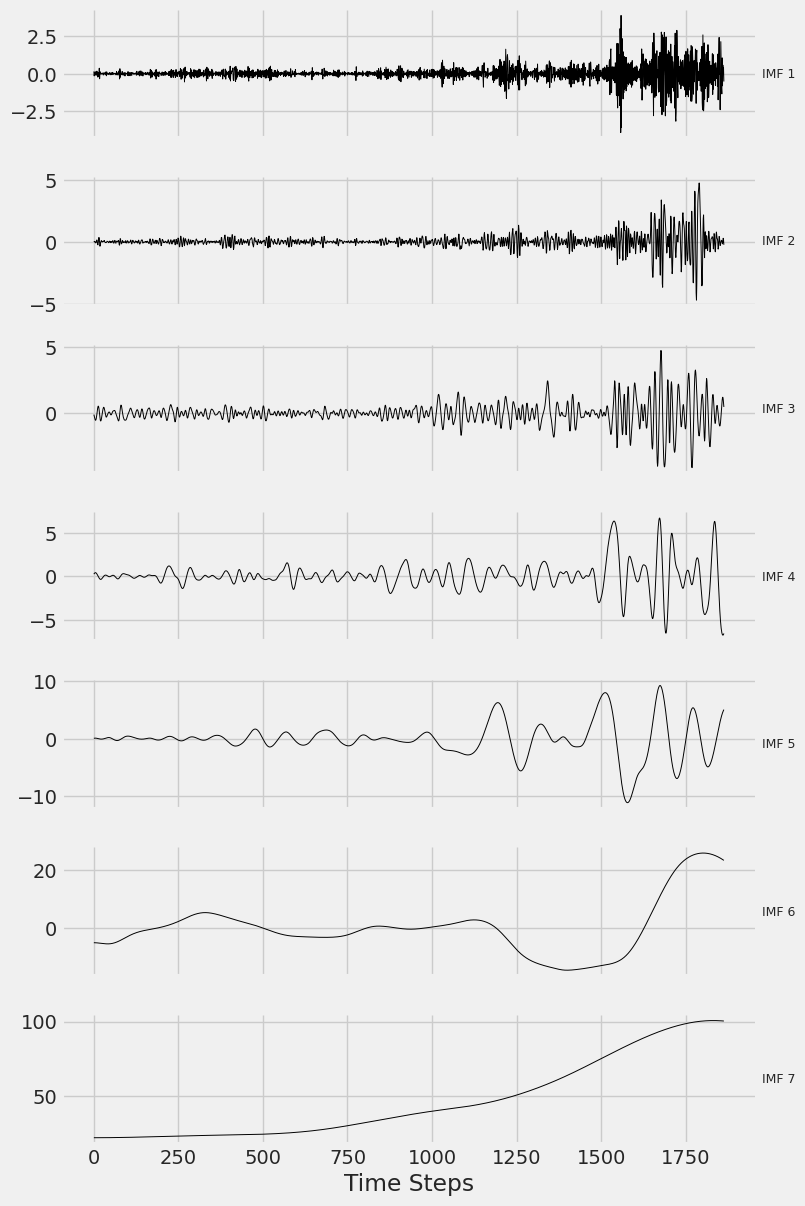

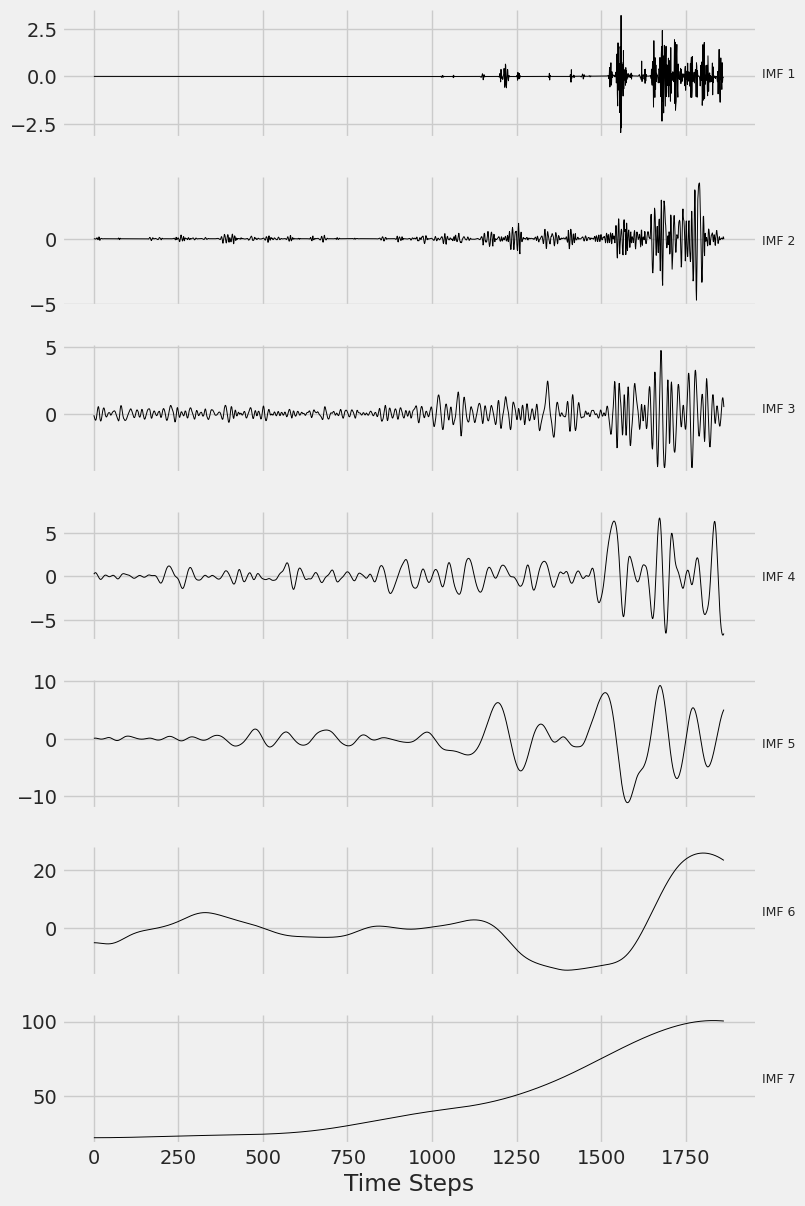

Close: 6 IMFs denoised


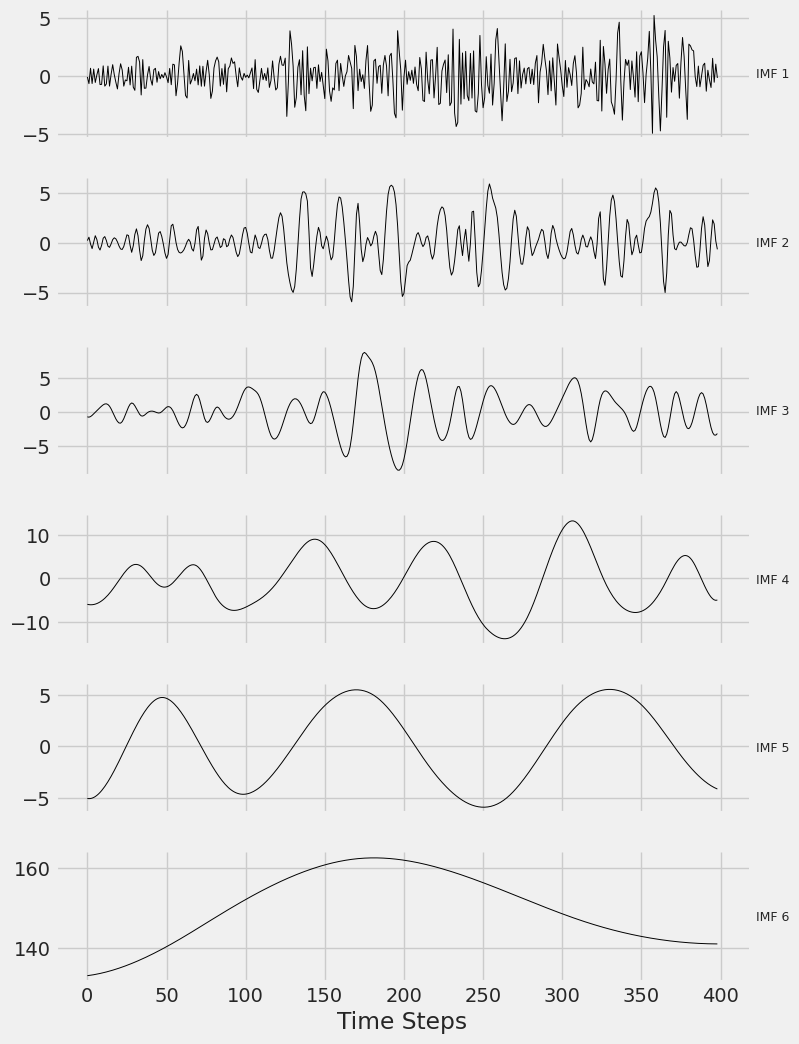

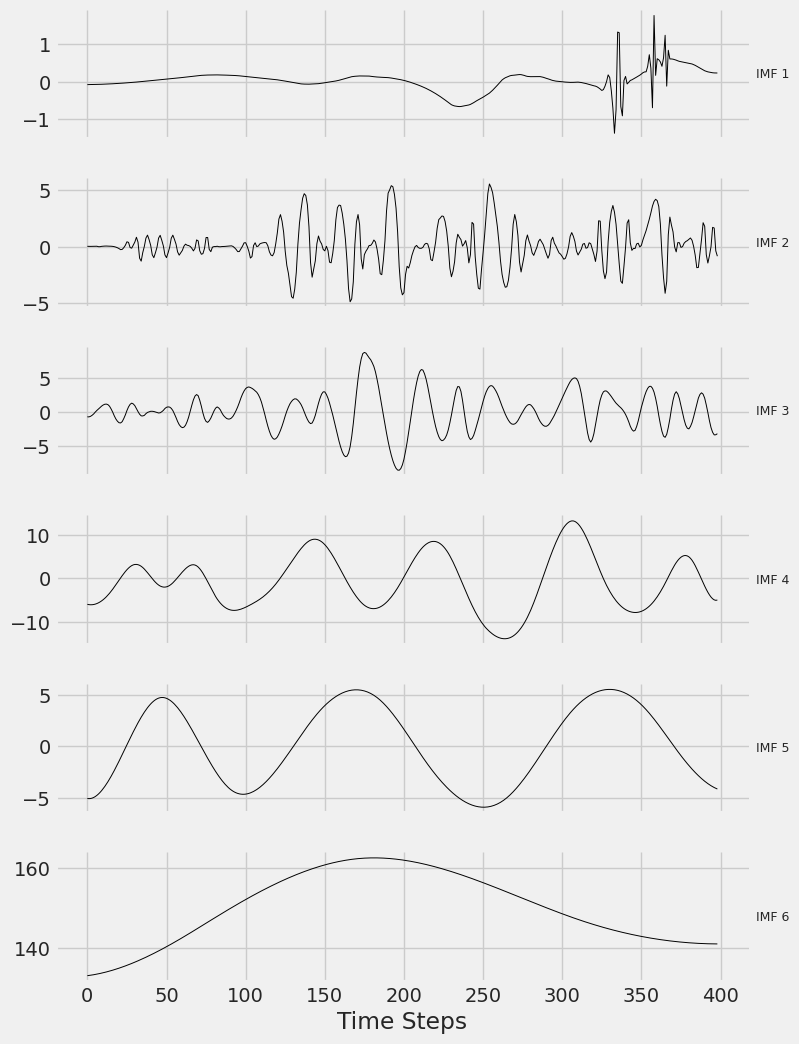

Close: 6 IMFs denoised


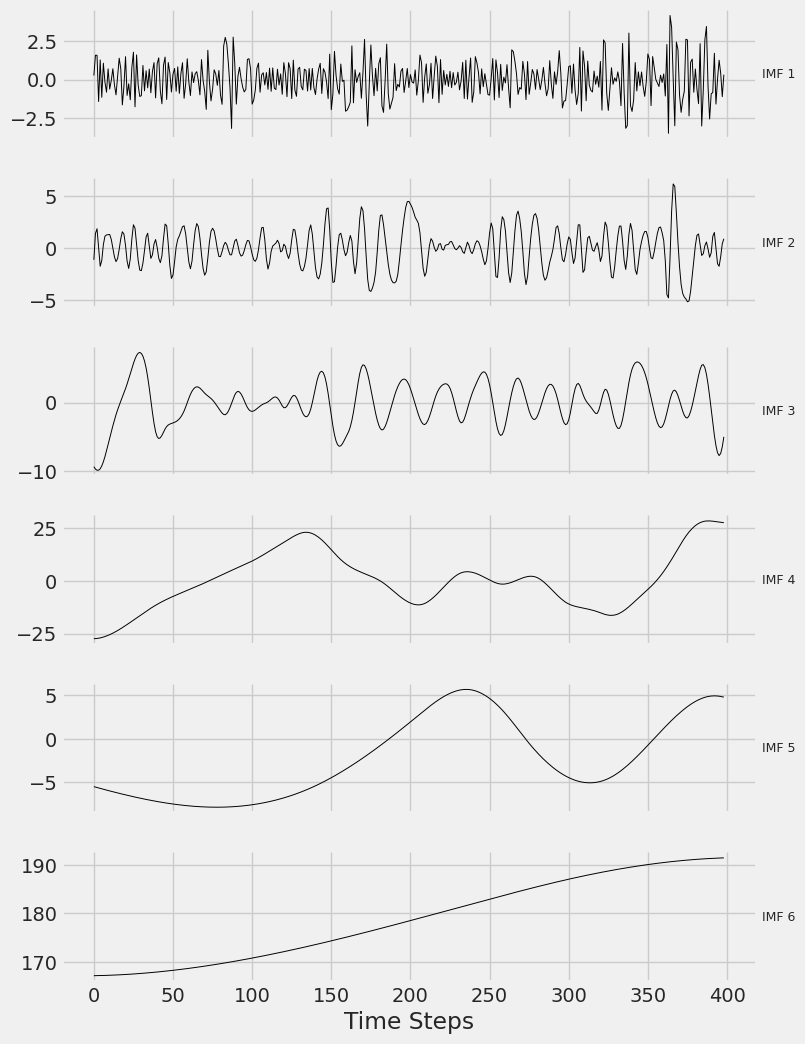

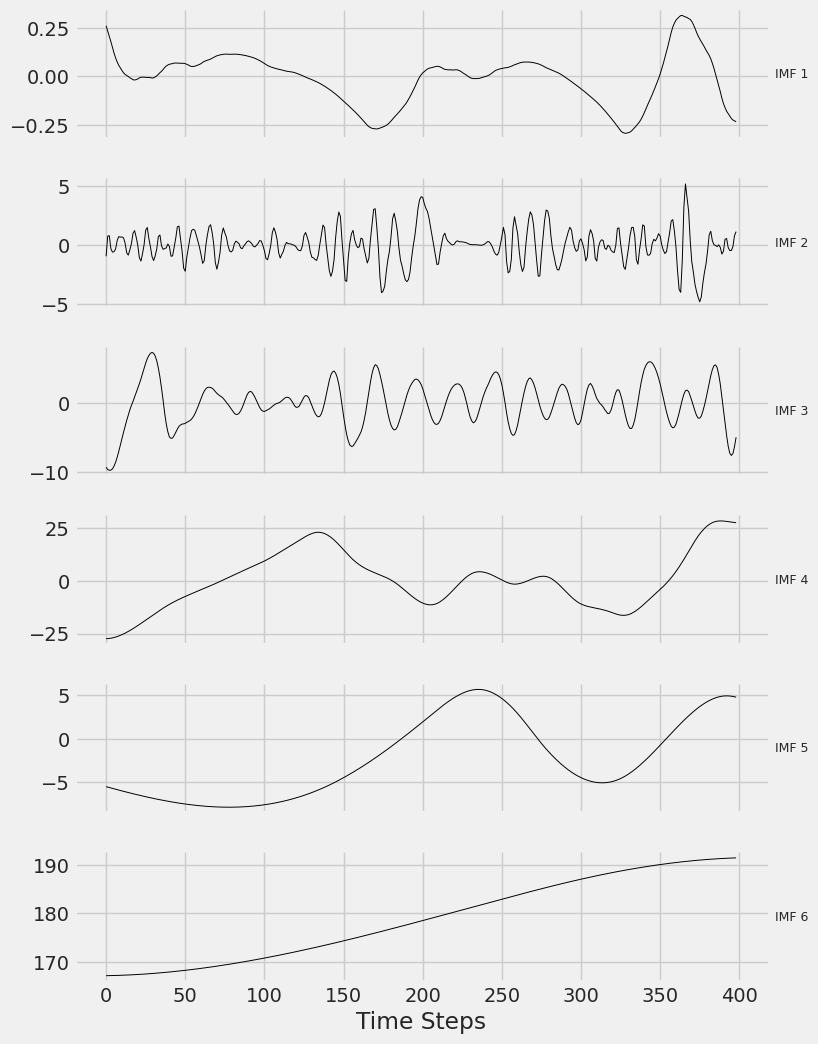

In [16]:
ceemdan_denoised_train_data = apply_ceemdan_denoise(train_data, ceemdan, split='train')
ceemdan_denoised_val_data = apply_ceemdan_denoise(val_data, ceemdan, split='val')
ceemdan_denoised_test_data = apply_ceemdan_denoise(test_data, ceemdan, split='test')

In [17]:
dain_forward = DAIN_Layer(mode='full', input_dim=1, isTarget=False)
dain_target = DAIN_Layer(mode='full', input_dim=1, isTarget=True)

In [18]:
scaled_train_data = apply_dain(pd.DataFrame(ceemdan_denoised_train_data), dain_forward)
scaled_val_data, val_adaptive_avg, val_adaptive_std, val_gate = apply_dain(pd.DataFrame(ceemdan_denoised_val_data), dain_target)
scaled_test_data, test_adaptive_avg, test_adaptive_std, test_gate = apply_dain(pd.DataFrame(ceemdan_denoised_test_data), dain_target)

In [19]:
scaled_train_data, scaled_val_data, scaled_test_data = np.array(scaled_train_data), np.array(scaled_val_data), np.array(scaled_test_data)

# Concatenate splits so validation/test windows can use prior context
full_scaled_data = np.vstack([scaled_train_data, scaled_val_data, scaled_test_data])
train_end = len(scaled_train_data)
val_end = train_end + len(scaled_val_data)

print("Data scaling completed.")

Data scaling completed.


## Sequence Construction and Sliding Window Tuning
Sequences are built from the full scaled series so validation/test windows retain context from prior splits.

In [20]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, GRU, Dropout
from keras.optimizers import Adam, SGD
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# training_callbacks = [
#     EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
# ]

EPOCHS = 50
BATCH_SIZE = 32

### Sliding Window Hyperparameter Tuning
We search over candidate lookback windows using a lightweight LSTM on the validation set, then lock in the best window for all model/optimizer comparisons.

In [21]:
def create_sequences(data, window_size, start_idx, end_idx):
    """Build (X, y) pairs from a contiguous scaled series slice."""
    x, y = [], []
    for i in range(start_idx + window_size, end_idx):
        x.append(data[i - window_size:i, 0])
        y.append(data[i, 0])
    x, y = np.array(x), np.array(y)
    return x.reshape(x.shape[0], x.shape[1], 1), y


def rmse_in_original_scale(y_scaled, y_pred_scaled, adaptive_avg, adaptive_std, adaptive_gate):
    y_true = inverse_dain(y_scaled, adaptive_avg, adaptive_std, adaptive_gate).reshape(-1, 1)
    y_pred = inverse_dain(y_pred_scaled, adaptive_avg, adaptive_std, adaptive_gate).reshape(-1, 1)
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [22]:
WINDOW_CANDIDATES = [30, 60, 90, 120]

### LSTM Adam Window Tuning

In [23]:
window_tuning_results_lstm_adam = []
best_window_size_lstm_adam = WINDOW_CANDIDATES[0]
best_window_val_rmse_lstm_adam = float('inf')

In [24]:
print('Tuning sliding window on validation RMSE...')
for candidate_window in WINDOW_CANDIDATES:
    x_tune_train, y_tune_train = create_sequences(full_scaled_data, candidate_window, 0, train_end)
    x_tune_val, y_tune_val = create_sequences(full_scaled_data, candidate_window, train_end, val_end)

    tune_model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(candidate_window, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    tune_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    tune_model.fit(
        x_tune_train, y_tune_train,
        validation_data=(x_tune_val, y_tune_val),
        batch_size=32,
        epochs=50,
        verbose=0,
        # callbacks=training_callbacks
    )

    val_predictions = tune_model.predict(x_tune_val, verbose=0)
    candidate_val_rmse = rmse_in_original_scale(y_tune_val, val_predictions, val_adaptive_avg, val_adaptive_std, val_gate)
    window_tuning_results_lstm_adam.append((candidate_window, candidate_val_rmse))
    print(f'  window={candidate_window:3d} -> validation RMSE: {candidate_val_rmse:.4f}')

    if candidate_val_rmse < best_window_val_rmse_lstm_adam:
        best_window_val_rmse_lstm_adam = candidate_val_rmse
        best_window_size_lstm_adam = candidate_window

print(f'\nSelected sliding window: {best_window_size_lstm_adam} (validation RMSE: {best_window_val_rmse_lstm_adam:.4f})')

x_train_lstm_adam, y_train_lstm_adam = create_sequences(full_scaled_data, best_window_size_lstm_adam, 0, train_end)
x_val_lstm_adam, y_val_lstm_adam = create_sequences(full_scaled_data, best_window_size_lstm_adam, train_end, val_end)
x_test_lstm_adam, y_test_lstm_adam = create_sequences(full_scaled_data, best_window_size_lstm_adam, val_end, len(full_scaled_data))

print('Data preparation completed.')
print(f'Train samples: {len(x_train_lstm_adam)}, Val samples: {len(x_val_lstm_adam)}, Test samples: {len(x_test_lstm_adam)}')

Tuning sliding window on validation RMSE...


I0000 00:00:1784218509.545181      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 30 -> validation RMSE: 3.5525


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 60 -> validation RMSE: 3.5661


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 90 -> validation RMSE: 3.4859


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window=120 -> validation RMSE: 3.9337

Selected sliding window: 90 (validation RMSE: 3.4859)
Data preparation completed.
Train samples: 1774, Val samples: 309, Test samples: 309


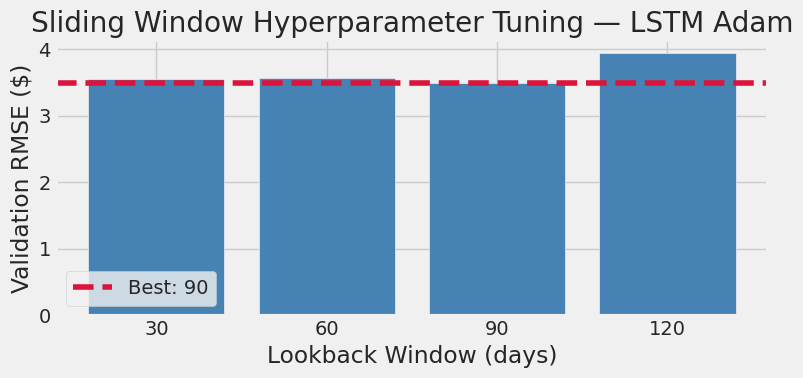

In [25]:
# Visualize sliding window tuning results
window_df = pd.DataFrame(window_tuning_results_lstm_adam, columns=['Window Size', 'Validation RMSE'])
plt.figure(figsize=(8, 4))
plt.bar(window_df['Window Size'].astype(str), window_df['Validation RMSE'], color='steelblue')
plt.axhline(best_window_val_rmse_lstm_adam, color='crimson', linestyle='--', label=f'Best: {best_window_size_lstm_adam}')
plt.title('Sliding Window Hyperparameter Tuning — LSTM Adam')
plt.xlabel('Lookback Window (days)')
plt.ylabel('Validation RMSE ($)')
plt.legend()
plt.tight_layout()
plt.show()

### GRU Adam Window Tuning

In [26]:
window_tuning_results_gru_adam = []
best_window_size_gru_adam = WINDOW_CANDIDATES[0]
best_window_val_rmse_gru_adam = float('inf')

In [27]:
print('Tuning sliding window on validation RMSE...')
for candidate_window in WINDOW_CANDIDATES:
    x_tune_train, y_tune_train = create_sequences(full_scaled_data, candidate_window, 0, train_end)
    x_tune_val, y_tune_val = create_sequences(full_scaled_data, candidate_window, train_end, val_end)

    tune_model = Sequential([
        GRU(64, return_sequences=True, input_shape=(candidate_window, 1)),
        Dropout(0.2),
        GRU(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    tune_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    tune_model.fit(
        x_tune_train, y_tune_train,
        validation_data=(x_tune_val, y_tune_val),
        batch_size=32,
        epochs=50,
        verbose=0,
        # callbacks=training_callbacks
    )

    val_predictions = tune_model.predict(x_tune_val, verbose=0)
    candidate_val_rmse = rmse_in_original_scale(y_tune_val, val_predictions, val_adaptive_avg, val_adaptive_std, val_gate)
    window_tuning_results_gru_adam.append((candidate_window, candidate_val_rmse))
    print(f'  window={candidate_window:3d} -> validation RMSE: {candidate_val_rmse:.4f}')

    if candidate_val_rmse < best_window_val_rmse_gru_adam:
        best_window_val_rmse_gru_adam = candidate_val_rmse
        best_window_size_gru_adam = candidate_window

print(f'\nSelected sliding window: {best_window_size_gru_adam} (validation RMSE: {best_window_val_rmse_gru_adam:.4f})')

x_train_gru_adam, y_train_gru_adam = create_sequences(full_scaled_data, best_window_size_gru_adam, 0, train_end)
x_val_gru_adam, y_val_gru_adam = create_sequences(full_scaled_data, best_window_size_gru_adam, train_end, val_end)
x_test_gru_adam, y_test_gru_adam = create_sequences(full_scaled_data, best_window_size_gru_adam, val_end, len(full_scaled_data))

print('Data preparation completed.')
print(f'Train samples: {len(x_train_gru_adam)}, Val samples: {len(x_val_gru_adam)}, Test samples: {len(x_test_gru_adam)}')

Tuning sliding window on validation RMSE...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 30 -> validation RMSE: 2.2945


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 60 -> validation RMSE: 2.5556


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 90 -> validation RMSE: 2.7830


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window=120 -> validation RMSE: 2.5208

Selected sliding window: 30 (validation RMSE: 2.2945)
Data preparation completed.
Train samples: 1834, Val samples: 369, Test samples: 369


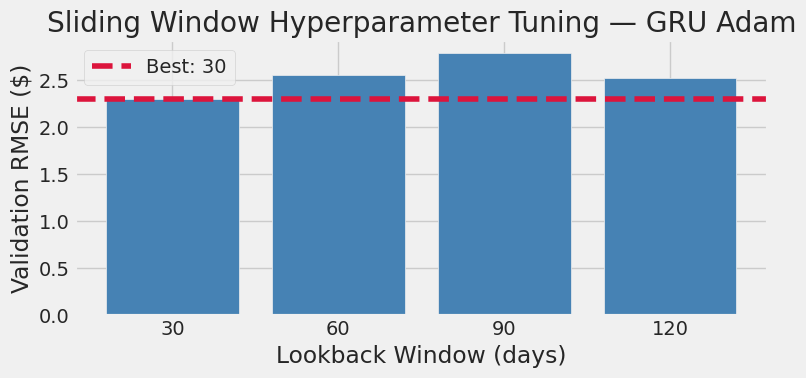

In [28]:
# Visualize sliding window tuning results
window_df = pd.DataFrame(window_tuning_results_gru_adam, columns=['Window Size', 'Validation RMSE'])
plt.figure(figsize=(8, 4))
plt.bar(window_df['Window Size'].astype(str), window_df['Validation RMSE'], color='steelblue')
plt.axhline(best_window_val_rmse_gru_adam, color='crimson', linestyle='--', label=f'Best: {best_window_size_gru_adam}')
plt.title('Sliding Window Hyperparameter Tuning — GRU Adam')
plt.xlabel('Lookback Window (days)')
plt.ylabel('Validation RMSE ($)')
plt.legend()
plt.tight_layout()
plt.show()

### LSTM NAG Window Tuning

In [29]:
window_tuning_results_lstm_nag = []
best_window_size_lstm_nag = WINDOW_CANDIDATES[0]
best_window_val_rmse_lstm_nag = float('inf')

In [30]:
print('Tuning sliding window on validation RMSE...')
for candidate_window in WINDOW_CANDIDATES:
    x_tune_train, y_tune_train = create_sequences(full_scaled_data, candidate_window, 0, train_end)
    x_tune_val, y_tune_val = create_sequences(full_scaled_data, candidate_window, train_end, val_end)

    tune_model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(candidate_window, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    tune_model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True), loss='mean_squared_error')
    tune_model.fit(
        x_tune_train, y_tune_train,
        validation_data=(x_tune_val, y_tune_val),
        batch_size=32,
        epochs=50,
        verbose=0,
        # callbacks=training_callbacks
    )

    val_predictions = tune_model.predict(x_tune_val, verbose=0)
    candidate_val_rmse = rmse_in_original_scale(y_tune_val, val_predictions, val_adaptive_avg, val_adaptive_std, val_gate)
    window_tuning_results_lstm_nag.append((candidate_window, candidate_val_rmse))
    print(f'  window={candidate_window:3d} -> validation RMSE: {candidate_val_rmse:.4f}')

    if candidate_val_rmse < best_window_val_rmse_lstm_nag:
        best_window_val_rmse_lstm_nag = candidate_val_rmse
        best_window_size_lstm_nag = candidate_window

print(f'\nSelected sliding window: {best_window_size_lstm_nag} (validation RMSE: {best_window_val_rmse_lstm_nag:.4f})')

x_train_lstm_nag, y_train_lstm_nag = create_sequences(full_scaled_data, best_window_size_lstm_nag, 0, train_end)
x_val_lstm_nag, y_val_lstm_nag = create_sequences(full_scaled_data, best_window_size_lstm_nag, train_end, val_end)
x_test_lstm_nag, y_test_lstm_nag = create_sequences(full_scaled_data, best_window_size_lstm_nag, val_end, len(full_scaled_data))

print('Data preparation completed.')
print(f'Train samples: {len(x_train_lstm_nag)}, Val samples: {len(x_val_lstm_nag)}, Test samples: {len(x_test_lstm_nag)}')


Tuning sliding window on validation RMSE...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 30 -> validation RMSE: 4.8486


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 60 -> validation RMSE: 5.1005


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 90 -> validation RMSE: 5.2897


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window=120 -> validation RMSE: 5.6530

Selected sliding window: 30 (validation RMSE: 4.8486)
Data preparation completed.
Train samples: 1834, Val samples: 369, Test samples: 369


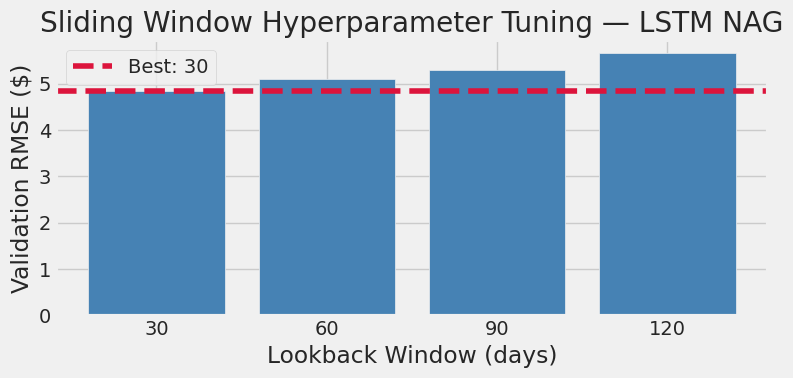

In [31]:
# Visualize sliding window tuning results
window_df = pd.DataFrame(window_tuning_results_lstm_nag, columns=['Window Size', 'Validation RMSE'])
plt.figure(figsize=(8, 4))
plt.bar(window_df['Window Size'].astype(str), window_df['Validation RMSE'], color='steelblue')
plt.axhline(best_window_val_rmse_lstm_nag, color='crimson', linestyle='--', label=f'Best: {best_window_size_lstm_nag}')
plt.title('Sliding Window Hyperparameter Tuning — LSTM NAG')
plt.xlabel('Lookback Window (days)')
plt.ylabel('Validation RMSE ($)')
plt.legend()
plt.tight_layout()
plt.show()

### GRU NAG Window Tuning

In [32]:
window_tuning_results_gru_nag = []
best_window_size_gru_nag = WINDOW_CANDIDATES[0]
best_window_val_rmse_gru_nag = float('inf')

In [33]:
print('Tuning sliding window on validation RMSE...')
for candidate_window in WINDOW_CANDIDATES:
    x_tune_train, y_tune_train = create_sequences(full_scaled_data, candidate_window, 0, train_end)
    x_tune_val, y_tune_val = create_sequences(full_scaled_data, candidate_window, train_end, val_end)

    tune_model = Sequential([
        GRU(64, return_sequences=True, input_shape=(candidate_window, 1)),
        Dropout(0.2),
        GRU(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    tune_model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True), loss='mean_squared_error')
    tune_model.fit(
        x_tune_train, y_tune_train,
        validation_data=(x_tune_val, y_tune_val),
        batch_size=32,
        epochs=50,
        verbose=0,
        # callbacks=training_callbacks
    )

    val_predictions = tune_model.predict(x_tune_val, verbose=0)
    candidate_val_rmse = rmse_in_original_scale(y_tune_val, val_predictions, val_adaptive_avg, val_adaptive_std, val_gate)
    window_tuning_results_gru_nag.append((candidate_window, candidate_val_rmse))
    print(f'  window={candidate_window:3d} -> validation RMSE: {candidate_val_rmse:.4f}')

    if candidate_val_rmse < best_window_val_rmse_gru_nag:
        best_window_val_rmse_gru_nag = candidate_val_rmse
        best_window_size_gru_nag = candidate_window

print(f'\nSelected sliding window: {best_window_size_gru_nag} (validation RMSE: {best_window_val_rmse_gru_nag:.4f})')

x_train_gru_nag, y_train_gru_nag = create_sequences(full_scaled_data, best_window_size_gru_nag, 0, train_end)
x_val_gru_nag, y_val_gru_nag = create_sequences(full_scaled_data, best_window_size_gru_nag, train_end, val_end)
x_test_gru_nag, y_test_gru_nag = create_sequences(full_scaled_data, best_window_size_gru_nag, val_end, len(full_scaled_data))

print('Data preparation completed.')
print(f'Train samples: {len(x_train_gru_nag)}, Val samples: {len(x_val_gru_nag)}, Test samples: {len(x_test_gru_nag)}')

Tuning sliding window on validation RMSE...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 30 -> validation RMSE: 3.6148


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 60 -> validation RMSE: 3.5810


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window= 90 -> validation RMSE: 3.8319


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  window=120 -> validation RMSE: 3.9149

Selected sliding window: 60 (validation RMSE: 3.5810)
Data preparation completed.
Train samples: 1804, Val samples: 339, Test samples: 339


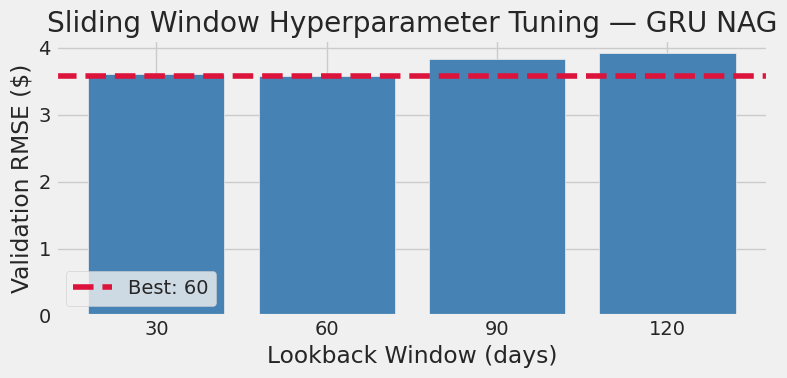

In [34]:
# Visualize sliding window tuning results
window_df = pd.DataFrame(window_tuning_results_gru_nag, columns=['Window Size', 'Validation RMSE'])
plt.figure(figsize=(8, 4))
plt.bar(window_df['Window Size'].astype(str), window_df['Validation RMSE'], color='steelblue')
plt.axhline(best_window_val_rmse_gru_nag, color='crimson', linestyle='--', label=f'Best: {best_window_size_gru_nag}')
plt.title('Sliding Window Hyperparameter Tuning — GRU NAG')
plt.xlabel('Lookback Window (days)')
plt.ylabel('Validation RMSE ($)')
plt.legend()
plt.tight_layout()
plt.show()

## Step 3: Building the LSTM and GRU Models


In [35]:
# Function to build the model
def build_model(model_type, optimizer, window_size):
    model = Sequential()
    if model_type == 'LSTM':
        model.add(LSTM(64, return_sequences=True, input_shape=(window_size, 1)))
        model.add(Dropout(0.2))
        model.add(LSTM(32, return_sequences=False))
        model.add(Dropout(0.2))
    elif model_type == 'GRU':
        model.add(GRU(64, return_sequences=True, input_shape=(window_size, 1)))
        model.add(Dropout(0.2))
        model.add(GRU(32, return_sequences=False))
        model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

print('Model building function defined.')


Model building function defined.


## Step 4: Training Models and Evaluating Performance


**Training LSTM with Adam**

In [36]:
# LSTM with Adam
optimizer_adam = Adam(learning_rate=0.001)
model_lstm_adam = build_model('LSTM', optimizer_adam, best_window_size_lstm_adam)
history_lstm_adam = model_lstm_adam.fit(
    x_train_lstm_adam, y_train_lstm_adam,
    validation_data=(x_val_lstm_adam, y_val_lstm_adam),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    # callbacks=training_callbacks,
    verbose=1
)
print('LSTM with Adam training completed.')


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0486 - val_loss: 0.0267
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0073 - val_loss: 0.0209
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0055 - val_loss: 0.0220
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0052 - val_loss: 0.0198
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0048 - val_loss: 0.0181
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0041 - val_loss: 0.0183
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0045 - val_loss: 0.0170
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0042 - val_loss: 0.0173
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0042 - val_loss: 0.0150
Epoch 10/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0040 - val_loss: 0.0150
Epoch 11/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0044 - val_loss: 0.0147
Epoch 12/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0038 - val_l

**Training LSTM with Nesterov (NAG)**


In [37]:
# LSTM with Nesterov
optimizer_nag = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_lstm_nag = build_model('LSTM', optimizer_nag, best_window_size_lstm_nag)
history_lstm_nag = model_lstm_nag.fit(
    x_train_lstm_nag, y_train_lstm_nag,
    validation_data=(x_val_lstm_nag, y_val_lstm_nag),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    # callbacks=training_callbacks,
    verbose=1
)
print('LSTM with Nesterov training completed.')


Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0249 - val_loss: 0.0195
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0082 - val_loss: 0.0213
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0066 - val_loss: 0.0188
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0052 - val_loss: 0.0178
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0053 - val_loss: 0.0171
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0055 - val_loss: 0.0178
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0045 - val_loss: 0.0164
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0051 - val_loss: 0.0151
Epoch 9/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0045 - val_loss: 0.0155
Epoch 10/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0043 - val_loss: 0.0153
Epoch 11/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0038 - val_loss: 0.0148
Epoch 12/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039 - val_l

**Training GRU with Adam**


In [38]:
# GRU with Adam
optimizer_adam_gru = Adam(learning_rate=0.001)
model_gru_adam = build_model('GRU', optimizer_adam_gru, best_window_size_gru_adam)
history_gru_adam = model_gru_adam.fit(
    x_train_gru_adam, y_train_gru_adam,
    validation_data=(x_val_gru_adam, y_val_gru_adam),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    # callbacks=training_callbacks,
    verbose=1
)
print('GRU with Adam training completed.')


Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0482 - val_loss: 0.0089
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0059 - val_loss: 0.0070
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0044 - val_loss: 0.0063
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0046 - val_loss: 0.0055
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0040 - val_loss: 0.0067
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0041 - val_loss: 0.0065
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 - val_loss: 0.0055
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0035 - val_loss: 0.0054
Epoch 9/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0032 - val_loss: 0.0055
Epoch 10/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0034 - val_loss: 0.0049
Epoch 11/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0040 - val_loss: 0.0049
Epoch 12/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0035 - val_l

**Training GRU with Nesterov (NAG)**


In [39]:
# GRU with Nesterov
optimizer_nag_gru = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model_gru_nag = build_model('GRU', optimizer_nag_gru, best_window_size_gru_nag)
history_gru_nag = model_gru_nag.fit(
    x_train_gru_nag, y_train_gru_nag,
    validation_data=(x_val_gru_nag, y_val_gru_nag),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    # callbacks=training_callbacks,
    verbose=1
)
print('GRU with Nesterov training completed.')


Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0266 - val_loss: 0.0078
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0067 - val_loss: 0.0071
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0070 - val_loss: 0.0080
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0060 - val_loss: 0.0074
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0054 - val_loss: 0.0073
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0062 - val_loss: 0.0077
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0050 - val_loss: 0.0071
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0050 - val_loss: 0.0069
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0047 - val_loss: 0.0075
Epoch 10/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0051 - val_loss: 0.0065
Epoch 11/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0047 - val_loss: 0.0072
Epoch 12/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0049 - val_l

## Step 4: Making Predictions and Evaluating Models


In [40]:
# Makes predictions with each model
def make_predictions(model, x_data, adaptive_avg, adaptive_std, adaptive_gate):
    predictions = model.predict(x_data, verbose=0)
    result = inverse_dain(predictions, adaptive_avg, adaptive_std, adaptive_gate)
    return result

y_test_actual_lstm_adam = inverse_dain(y_test_lstm_adam, test_adaptive_avg, test_adaptive_std, test_gate)
y_test_actual_lstm_nag = inverse_dain(y_test_lstm_nag, test_adaptive_avg, test_adaptive_std, test_gate)
y_test_actual_gru_adam = inverse_dain(y_test_gru_adam, test_adaptive_avg, test_adaptive_std, test_gate)
y_test_actual_gru_nag = inverse_dain(y_test_gru_nag, test_adaptive_avg, test_adaptive_std, test_gate)

pred_lstm_adam = make_predictions(model_lstm_adam, x_test_lstm_adam, test_adaptive_avg, test_adaptive_std, test_gate)
pred_lstm_nag = make_predictions(model_lstm_nag, x_test_lstm_nag, test_adaptive_avg, test_adaptive_std, test_gate)
pred_gru_adam = make_predictions(model_gru_adam, x_test_gru_adam, test_adaptive_avg, test_adaptive_std, test_gate)
pred_gru_nag = make_predictions(model_gru_nag, x_test_gru_nag, test_adaptive_avg, test_adaptive_std, test_gate)

# Metrics in original price scale
rmse_lstm_adam = np.sqrt(mean_squared_error(y_test_actual_lstm_adam, pred_lstm_adam))
rmse_lstm_nag = np.sqrt(mean_squared_error(y_test_actual_lstm_nag, pred_lstm_nag))
rmse_gru_adam = np.sqrt(mean_squared_error(y_test_actual_gru_adam, pred_gru_adam))
rmse_gru_nag = np.sqrt(mean_squared_error(y_test_actual_gru_nag, pred_gru_nag))

mae_lstm_adam = mean_absolute_error(y_test_actual_lstm_adam, pred_lstm_adam)
mae_lstm_nag = mean_absolute_error(y_test_actual_lstm_nag, pred_lstm_nag)
mae_gru_adam = mean_absolute_error(y_test_actual_gru_adam, pred_gru_adam)
mae_gru_nag = mean_absolute_error(y_test_actual_gru_nag, pred_gru_nag)

r2_lstm_adam = r2_score(y_test_actual_lstm_adam, pred_lstm_adam)
r2_lstm_nag = r2_score(y_test_actual_lstm_nag, pred_lstm_nag)
r2_gru_adam = r2_score(y_test_actual_gru_adam, pred_gru_adam)
r2_gru_nag = r2_score(y_test_actual_gru_nag, pred_gru_nag)

metrics_values = {
    'LSTM Adam': {'RMSE': rmse_lstm_adam, 'MAE': mae_lstm_adam, 'R2': r2_lstm_adam},
    'LSTM NAG':  {'RMSE': rmse_lstm_nag,  'MAE': mae_lstm_nag,  'R2': r2_lstm_nag},
    'GRU Adam':  {'RMSE': rmse_gru_adam,  'MAE': mae_gru_adam,  'R2': r2_gru_adam},
    'GRU NAG':   {'RMSE': rmse_gru_nag,   'MAE': mae_gru_nag,   'R2': r2_gru_nag},
}

# Keep rmse_values for any later cells that still expect it
rmse_values = {name: m['RMSE'] for name, m in metrics_values.items()}

print('Predictions and metric calculations completed.')
for model_name, m in metrics_values.items():
    print(f"  {model_name}: RMSE = {m['RMSE']:.4f} | MAE = {m['MAE']:.4f} | R^2 = {m['R2']:.4f}")

Predictions and metric calculations completed.
  LSTM Adam: RMSE = 3.3119 | MAE = 2.5699 | R^2 = 0.9480
  LSTM NAG: RMSE = 4.5479 | MAE = 3.5167 | R^2 = 0.9292
  GRU Adam: RMSE = 2.5237 | MAE = 1.9415 | R^2 = 0.9782
  GRU NAG: RMSE = 3.2815 | MAE = 2.5138 | R^2 = 0.9533


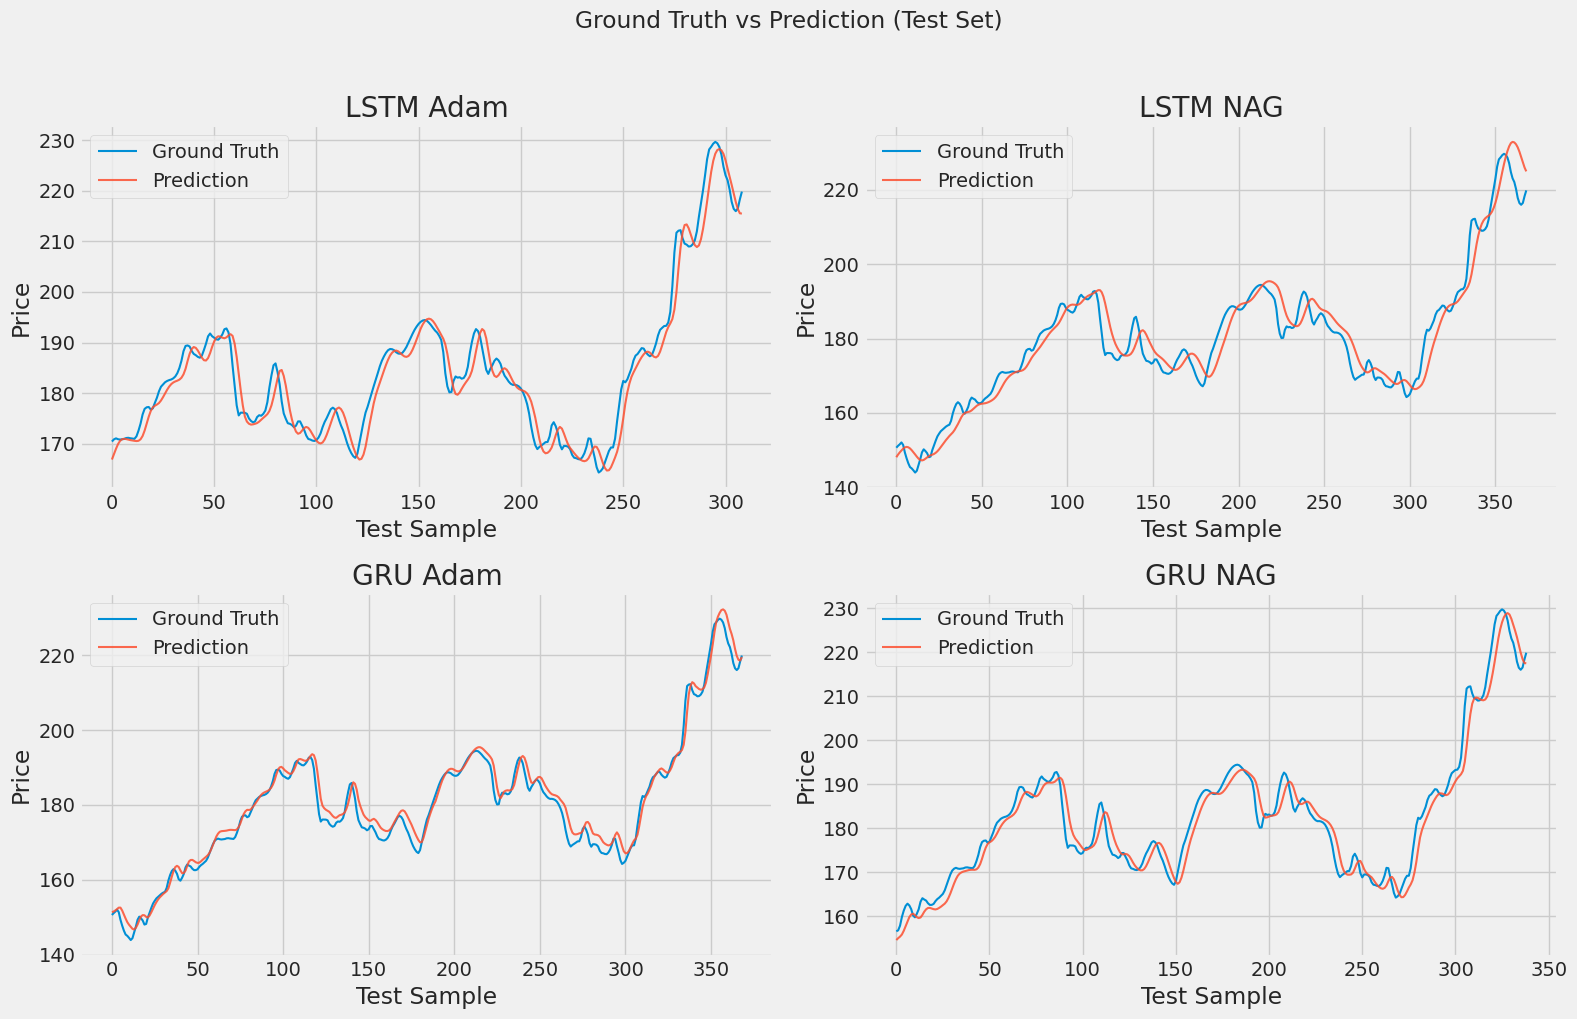

In [41]:
# Ground truth vs prediction for every model
prediction_plots = [
    ('LSTM Adam', y_test_actual_lstm_adam, pred_lstm_adam),
    ('LSTM NAG',  y_test_actual_lstm_nag,  pred_lstm_nag),
    ('GRU Adam',  y_test_actual_gru_adam,  pred_gru_adam),
    ('GRU NAG',   y_test_actual_gru_nag,   pred_gru_nag),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
axes = axes.flatten()

for ax, (name, y_true, y_pred) in zip(axes, prediction_plots):
    ax.plot(y_true, label='Ground Truth', linewidth=1.5)
    ax.plot(y_pred, label='Prediction', linewidth=1.5, alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel('Test Sample')
    ax.set_ylabel('Price')
    ax.legend()

plt.suptitle('Ground Truth vs Prediction (Test Set)', y=1.02)
plt.tight_layout()
plt.show()

## Step 5: Visualizations and Analysis
Visualizations included are:
* Line Plot of Loss vs. Epochs
* Line Plot of Log(Loss) vs. Epochs
* Bar chart of Final loss by Model-Optimizer Combination
* RMSE Summary table
* Training and Validation Loss Heatmaps



**Line Plot of Loss vs. Epochs**

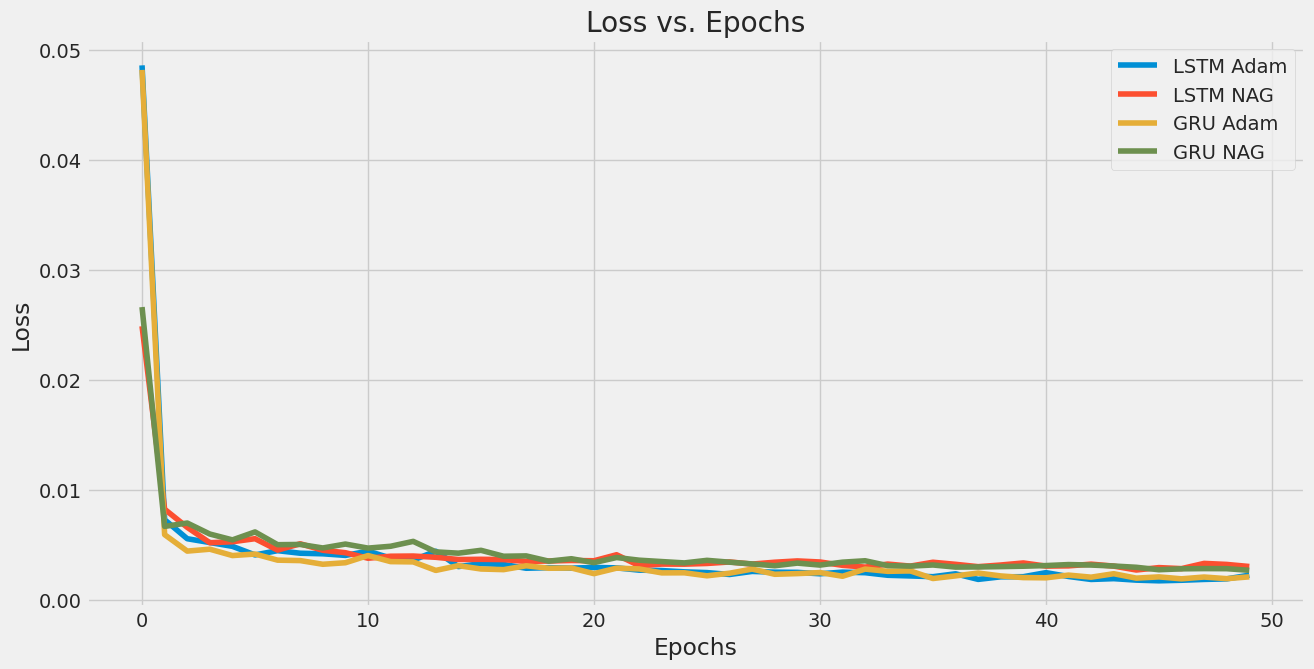

Loss vs. Epochs plot generated.


In [42]:
# Line Plot of Loss vs. Epochs
plt.figure(figsize=(14, 7))
plt.plot(history_lstm_adam.history['loss'], label='LSTM Adam')
plt.plot(history_lstm_nag.history['loss'], label='LSTM NAG')
plt.plot(history_gru_adam.history['loss'], label='GRU Adam')
plt.plot(history_gru_nag.history['loss'], label='GRU NAG')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print("Loss vs. Epochs plot generated.")

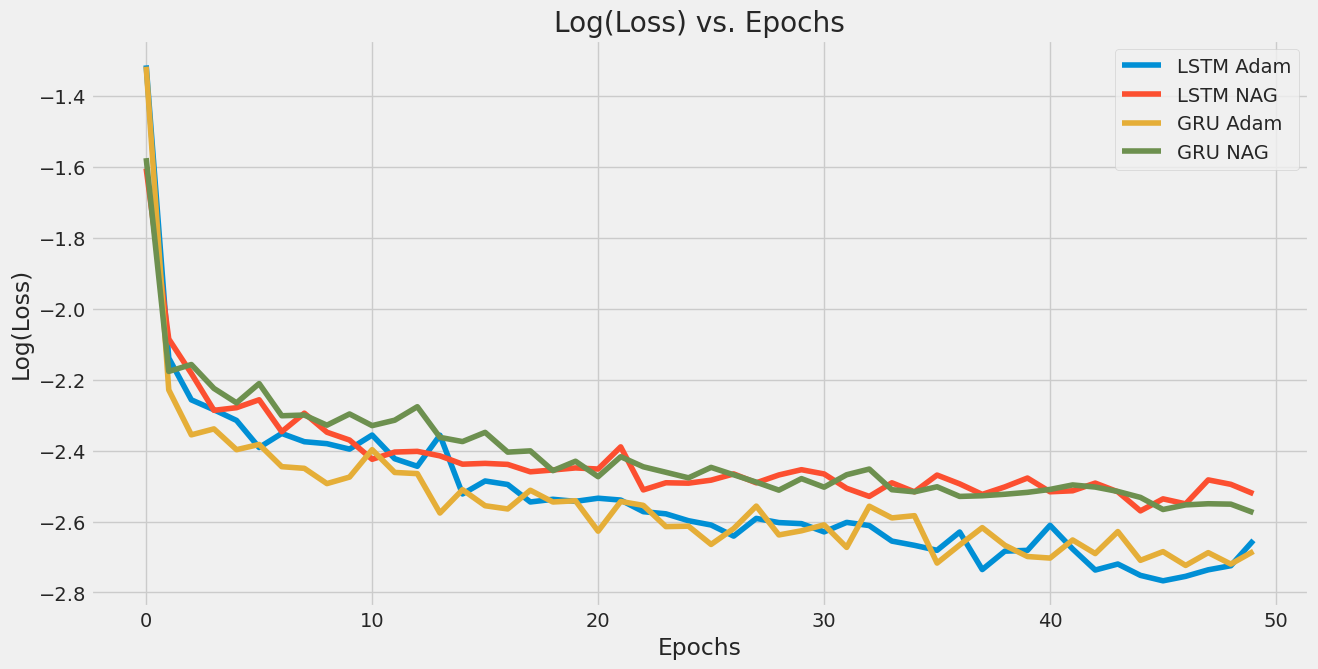

Convergence curves generated.


In [43]:
# Convergence Curves
plt.figure(figsize=(14, 7))
plt.plot(np.log10(history_lstm_adam.history['loss']), label='LSTM Adam')
plt.plot(np.log10(history_lstm_nag.history['loss']), label='LSTM NAG')
plt.plot(np.log10(history_gru_adam.history['loss']), label='GRU Adam')
plt.plot(np.log10(history_gru_nag.history['loss']), label='GRU NAG')
plt.title('Log(Loss) vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Log(Loss)')
plt.legend()
plt.show()

print("Convergence curves generated.")


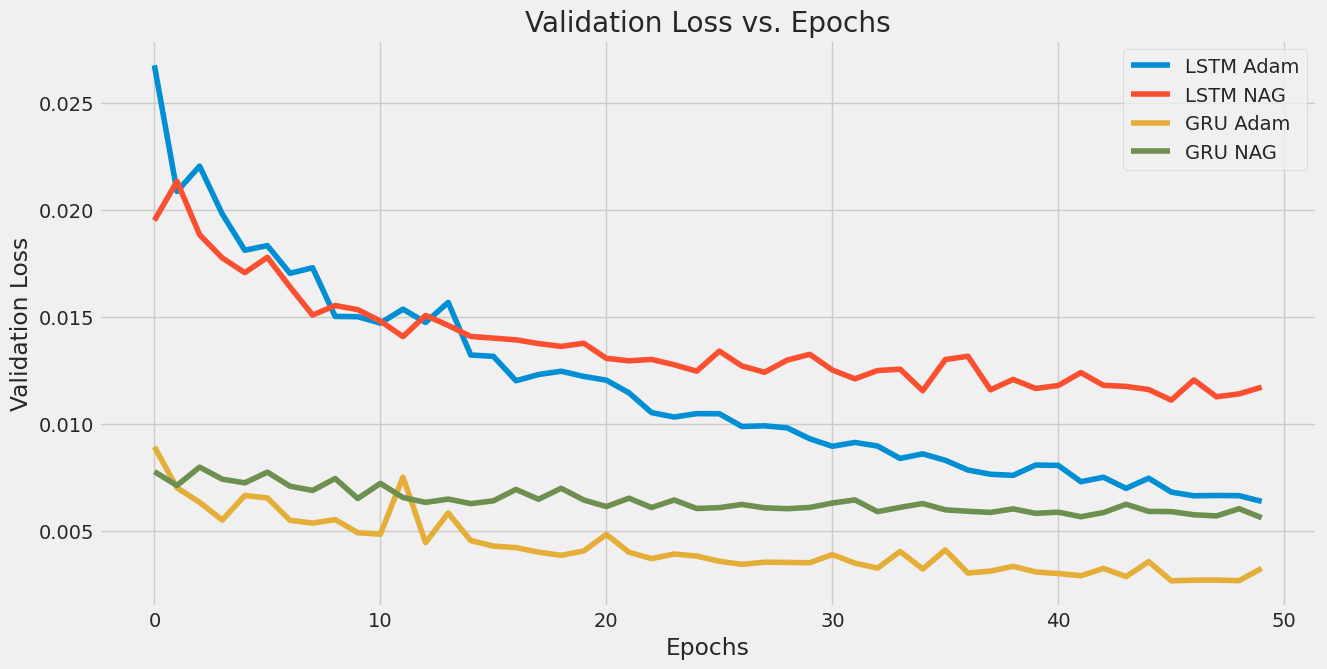

Validation Loss vs. Epochs plot generated.


In [44]:
# Line Plot of Validation Loss vs. Epochs
plt.figure(figsize=(14, 7))
plt.plot(history_lstm_adam.history['val_loss'], label='LSTM Adam')
plt.plot(history_lstm_nag.history['val_loss'], label='LSTM NAG')
plt.plot(history_gru_adam.history['val_loss'], label='GRU Adam')
plt.plot(history_gru_nag.history['val_loss'], label='GRU NAG')
plt.title('Validation Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

print("Validation Loss vs. Epochs plot generated.")

**Bar Charts of Final Loss**

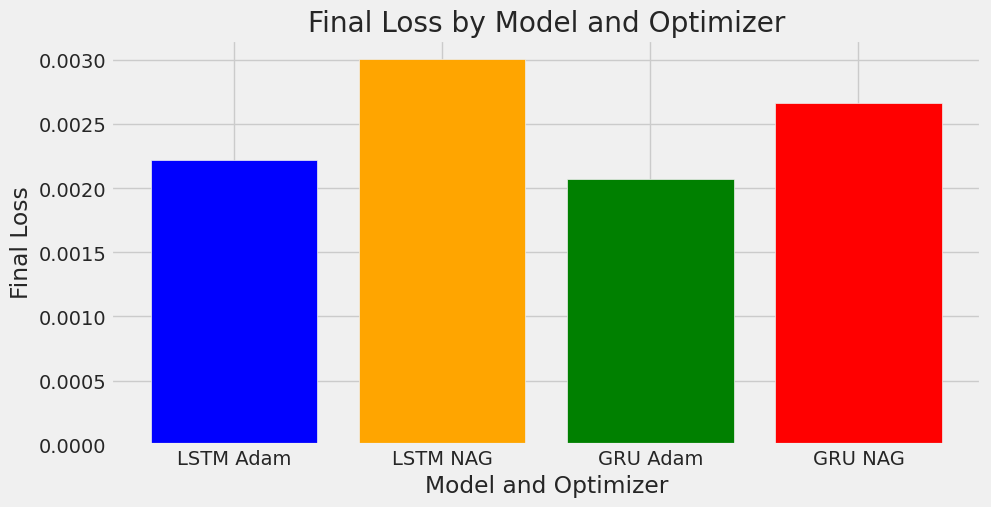

Final Loss bar chart generated.


In [45]:
# Bar Chart of Final Loss
final_losses = [
    history_lstm_adam.history['loss'][-1],
    history_lstm_nag.history['loss'][-1],
    history_gru_adam.history['loss'][-1],
    history_gru_nag.history['loss'][-1]
]

models = ['LSTM Adam', 'LSTM NAG', 'GRU Adam', 'GRU NAG']

plt.figure(figsize=(10, 5))
plt.bar(models, final_losses, color=['blue', 'orange', 'green', 'red'])
plt.title('Final Loss by Model and Optimizer')
plt.xlabel('Model and Optimizer')
plt.ylabel('Final Loss')
plt.show()

print("Final Loss bar chart generated.")


**Metrics Summary Table**

In [46]:
# Metrics Summary Table
metrics_table = [
    [model, f"{m['RMSE']:.4f}", f"{m['MAE']:.4f}", f"{m['R2']:.4f}"]
    for model, m in metrics_values.items()
]
print(tabulate(
    metrics_table,
    headers=['Model & Optimizer', 'RMSE', 'MAE', 'R^2'],
    tablefmt='pretty'
))

print("Metrics summary table generated.")

+-------------------+--------+--------+--------+
| Model & Optimizer |  RMSE  |  MAE   |  R^2   |
+-------------------+--------+--------+--------+
|     LSTM Adam     | 3.3119 | 2.5699 | 0.9480 |
|     LSTM NAG      | 4.5479 | 3.5167 | 0.9292 |
|     GRU Adam      | 2.5237 | 1.9415 | 0.9782 |
|      GRU NAG      | 3.2815 | 2.5138 | 0.9533 |
+-------------------+--------+--------+--------+
Metrics summary table generated.


**Heatmaps for summary**


In [47]:
# Extract loss and validation loss values automatically from training history
lstm_adam_loss = history_lstm_adam.history['loss']
lstm_adam_val_loss = history_lstm_adam.history['val_loss']

lstm_nag_loss = history_lstm_nag.history['loss']
lstm_nag_val_loss = history_lstm_nag.history['val_loss']

gru_adam_loss = history_gru_adam.history['loss']
gru_adam_val_loss = history_gru_adam.history['val_loss']

gru_nag_loss = history_gru_nag.history['loss']
gru_nag_val_loss = history_gru_nag.history['val_loss']


In [48]:
# Convert lists into a DataFrame (variable epoch count due to early stopping)
max_epoch_count = max(
    len(history_lstm_adam.history['loss']),
    len(history_lstm_nag.history['loss']),
    len(history_gru_adam.history['loss']),
    len(history_gru_nag.history['loss'])
)
epochs = np.arange(1, max_epoch_count + 1)
data = {
    'Epoch': epochs,
    'LSTM Adam Loss': lstm_adam_loss + [np.nan] * (max_epoch_count - len(lstm_adam_loss)),
    'LSTM NAG Loss': lstm_nag_loss + [np.nan] * (max_epoch_count - len(lstm_nag_loss)),
    'GRU Adam Loss': gru_adam_loss + [np.nan] * (max_epoch_count - len(gru_adam_loss)),
    'GRU NAG Loss': gru_nag_loss + [np.nan] * (max_epoch_count - len(gru_nag_loss)),
    'LSTM Adam Val Loss': lstm_adam_val_loss + [np.nan] * (max_epoch_count - len(lstm_adam_val_loss)),
    'LSTM NAG Val Loss': lstm_nag_val_loss + [np.nan] * (max_epoch_count - len(lstm_nag_val_loss)),
    'GRU Adam Val Loss': gru_adam_val_loss + [np.nan] * (max_epoch_count - len(gru_adam_val_loss)),
    'GRU NAG Val Loss': gru_nag_val_loss + [np.nan] * (max_epoch_count - len(gru_nag_val_loss)),
}
df_losses = pd.DataFrame(data)
df_losses


,Epoch,LSTM Adam Loss,LSTM NAG Loss,GRU Adam Loss,GRU NAG Loss,LSTM Adam Val Loss,LSTM NAG Val Loss,GRU Adam Val Loss,GRU NAG Val Loss
0,1,0.048573,0.024861,0.048159,0.026597,0.026739,0.019498,0.008935,0.007773
1,2,0.007265,0.008219,0.005907,0.006657,0.020851,0.021324,0.007018,0.007129
2,3,0.005536,0.006572,0.004411,0.006963,0.022035,0.018833,0.006341,0.007985
3,4,0.005191,0.005171,0.004585,0.005963,0.019807,0.017752,0.005513,0.007422
4,5,0.004844,0.005262,0.004006,0.005430,0.018108,0.017061,0.006659,0.007251
5,6,0.004062,0.005539,0.004144,0.006153,0.018327,0.017777,0.006546,0.007749
6,7,0.004451,0.004501,0.003588,0.004993,0.017032,0.016398,0.005503,0.007093
7,8,0.004218,0.005077,0.003549,0.005015,0.017290,0.015081,0.005370,0.006896
8,9,0.004165,0.004486,0.003214,0.004696,0.015019,0.015529,0.005535,0.007451
9,10,0.004020,0.004264,0.003353,0.005051,0.015006,0.015334,0.004923,0.006520


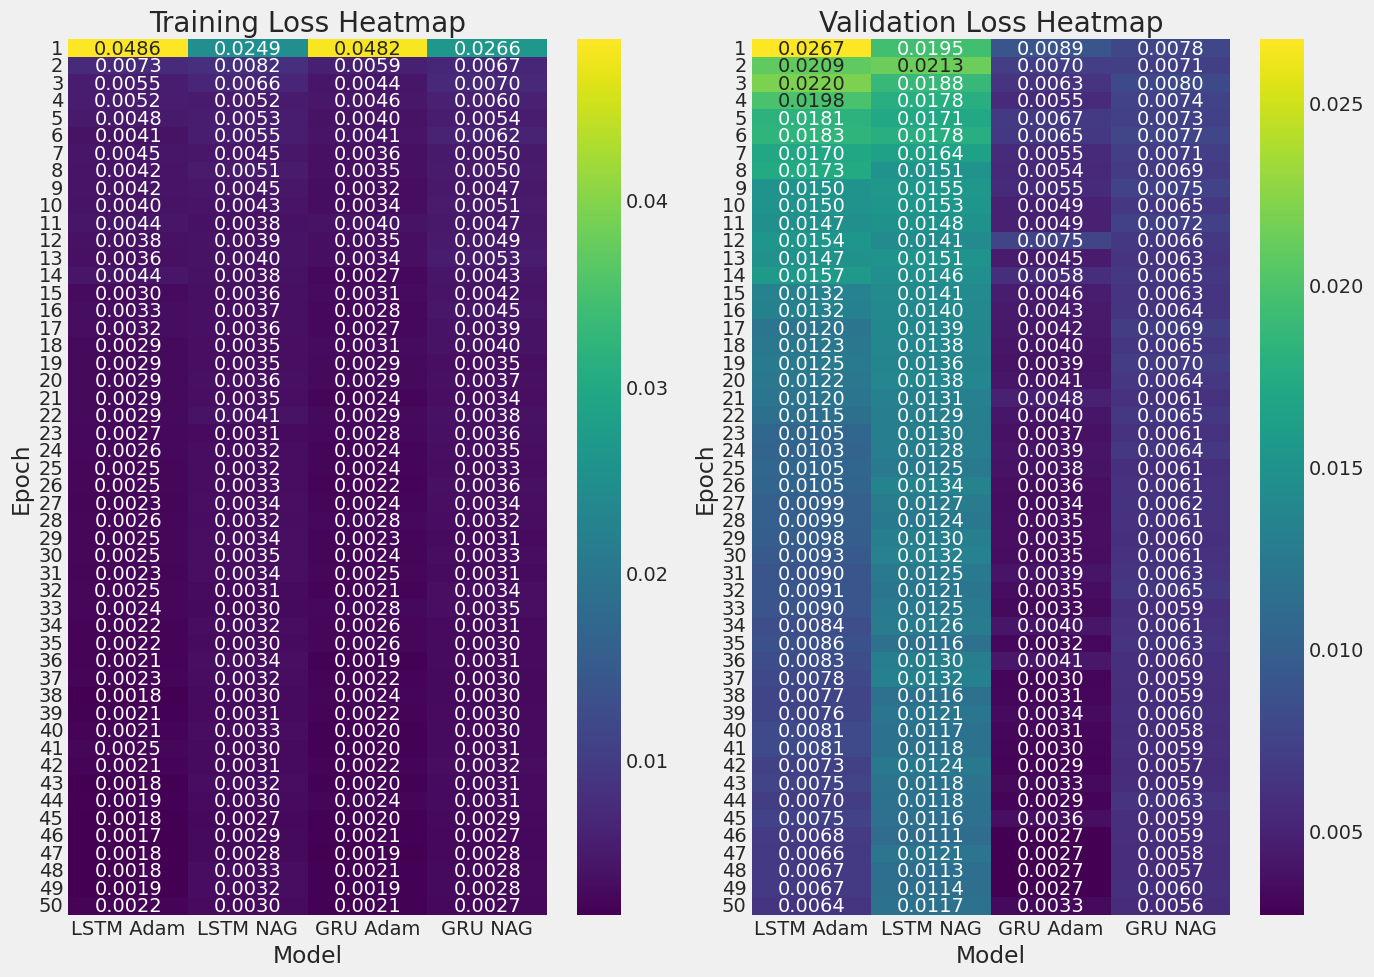

In [49]:
# Create heatmaps for loss values
plt.figure(figsize=(14, 10))

loss_cols = ['LSTM Adam Loss', 'LSTM NAG Loss', 'GRU Adam Loss', 'GRU NAG Loss']
val_cols = ['LSTM Adam Val Loss', 'LSTM NAG Val Loss', 'GRU Adam Val Loss', 'GRU NAG Val Loss']
epoch_labels = df_losses['Epoch'].astype(int).tolist()

plt.subplot(1, 2, 1)
sns.heatmap(
    df_losses[loss_cols].values,
    annot=True, cmap='viridis', fmt='.4f',
    xticklabels=['LSTM Adam', 'LSTM NAG', 'GRU Adam', 'GRU NAG'],
    yticklabels=epoch_labels
)
plt.title('Training Loss Heatmap')
plt.xlabel('Model')
plt.ylabel('Epoch')

plt.subplot(1, 2, 2)
sns.heatmap(
    df_losses[val_cols].values,
    annot=True, cmap='viridis', fmt='.4f',
    xticklabels=['LSTM Adam', 'LSTM NAG', 'GRU Adam', 'GRU NAG'],
    yticklabels=epoch_labels
)
plt.title('Validation Loss Heatmap')
plt.xlabel('Model')
plt.ylabel('Epoch')

plt.tight_layout()
plt.show()


**Training Loss Histogram**

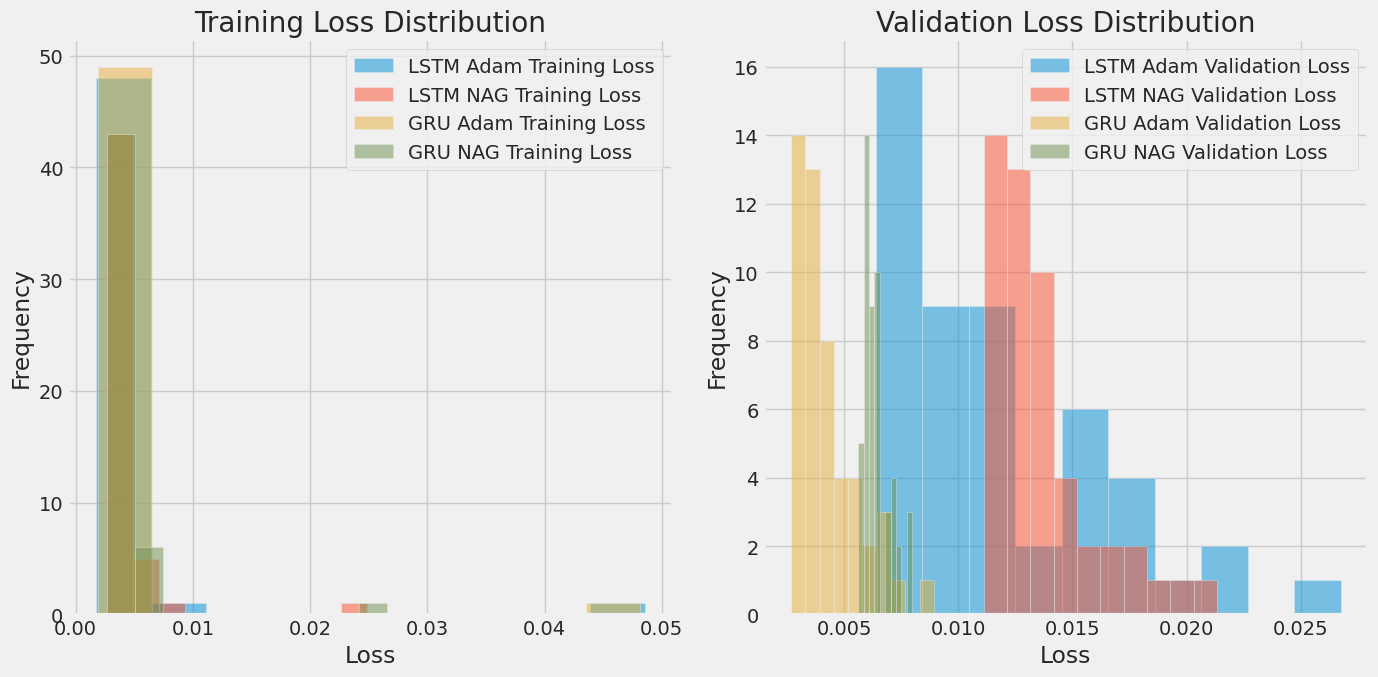

In [50]:
plt.figure(figsize=(14, 7))

# Training loss histogram
plt.subplot(1, 2, 1)
plt.hist(lstm_adam_loss, bins=10, alpha=0.5, label='LSTM Adam Training Loss')
plt.hist(lstm_nag_loss, bins=10, alpha=0.5, label='LSTM NAG Training Loss')
plt.hist(gru_adam_loss, bins=10, alpha=0.5, label='GRU Adam Training Loss')
plt.hist(gru_nag_loss, bins=10, alpha=0.5, label='GRU NAG Training Loss')
plt.title('Training Loss Distribution')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.legend()

# Validation loss histogram
plt.subplot(1, 2, 2)
plt.hist(lstm_adam_val_loss, bins=10, alpha=0.5, label='LSTM Adam Validation Loss')
plt.hist(lstm_nag_val_loss, bins=10, alpha=0.5, label='LSTM NAG Validation Loss')
plt.hist(gru_adam_val_loss, bins=10, alpha=0.5, label='GRU Adam Validation Loss')
plt.hist(gru_nag_val_loss, bins=10, alpha=0.5, label='GRU NAG Validation Loss')
plt.title('Validation Loss Distribution')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()
